# Supplementary for Efficacy-at-Recurrent Input

Kai Sandbrink

2025-11-07

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
import pickle
from utils import format_axis

if os.getcwd().endswith('scripts'):
    os.chdir('..')

analysis_folder = os.path.join('panels', 'fig_nns')
os.makedirs(analysis_folder, exist_ok=True)

effs = np.arange(0, 1.1, 0.125)

## Panel A: Learning Curves

In [ ]:
from settings_ana import pepe_nn_efficacy_at_recurrent_models as ape_models

ape_modelname = ape_models[0]

eval_folder = os.path.join('data', 'nns', 'eval', 'pepe')

### APE MODEL

from settings_ana import pepe_nn_ape_lc_timestamp as eval_timestamp

ape_test_rews = []
ape_test_apes_losses = []
ape_test_returns_losses = []
ape_test_apes_mses = []

for ape_model in ape_models:
    ape_test_rews.append(pickle.load(open(os.path.join(eval_folder, str(ape_model), eval_timestamp + '_test_learning_curve_rews.pkl'), 'rb')))
    ape_test_returns_losses.append(pickle.load(open(os.path.join(eval_folder, str(ape_model), eval_timestamp + '_test_learning_curve_returns_losses.pkl'), 'rb')))
    ape_test_apes_losses.append(pickle.load(open(os.path.join(eval_folder, str(ape_model), eval_timestamp + '_test_learning_curve_apes_losses.pkl'), 'rb')))
    ape_test_apes_mses.append(pickle.load(open(os.path.join(eval_folder, str(ape_model), eval_timestamp + '_test_learning_curve_apes_mses.pkl'), 'rb')))

test_episodes = pickle.load(open(os.path.join(eval_folder, str(ape_modelname), eval_timestamp + '_test_learning_curve_episodes.pkl'), 'rb'))

## average out along efficacy settings
ape_test_rews = np.array(ape_test_rews).mean(axis=2)

### THEORY
rews_pomdp = [25,25,25.33,26.12,27.05,28.06,29.13,30.23,31.36]


[16.25044444 17.58422222 17.93444444 18.37888889 18.69455556 18.91455556
 19.83933333 20.229      21.35066667 22.591      22.25655556 22.23611111
 23.17777778 24.27066667 25.10433333 25.06155556 25.65477778 25.162
 26.16455556 26.17888889 25.96688889 25.90877778 26.50577778 25.97333333
 26.36888889 26.07211111 26.44677778 26.54133333 26.73855556 26.63944444
 25.83588889 26.00333333 26.34655556 26.47188889 25.988      26.528
 26.75888889 26.48844444 26.60322222 26.52611111 26.61955556 26.55388889
 26.35377778 26.13788889 26.52577778 26.35166667 26.165      26.19933333
 26.21733333 26.36955556 26.37844444 26.32222222 26.53333333 26.47644444
 26.47488889 26.38733333 26.59322222 26.60866667 26.66444444 26.77833333
 26.56444444 26.85955556 26.62311111 26.54088889 26.60277778 26.52866667
 26.52788889 26.36633333 26.42177778 26.40955556 26.16255556 26.16733333
 26.56611111 26.54433333 26.55333333 26.76988889 26.63222222 26.75611111
 26.77244444 26.47122222 26.33133333 26.39166667 26.41977778 

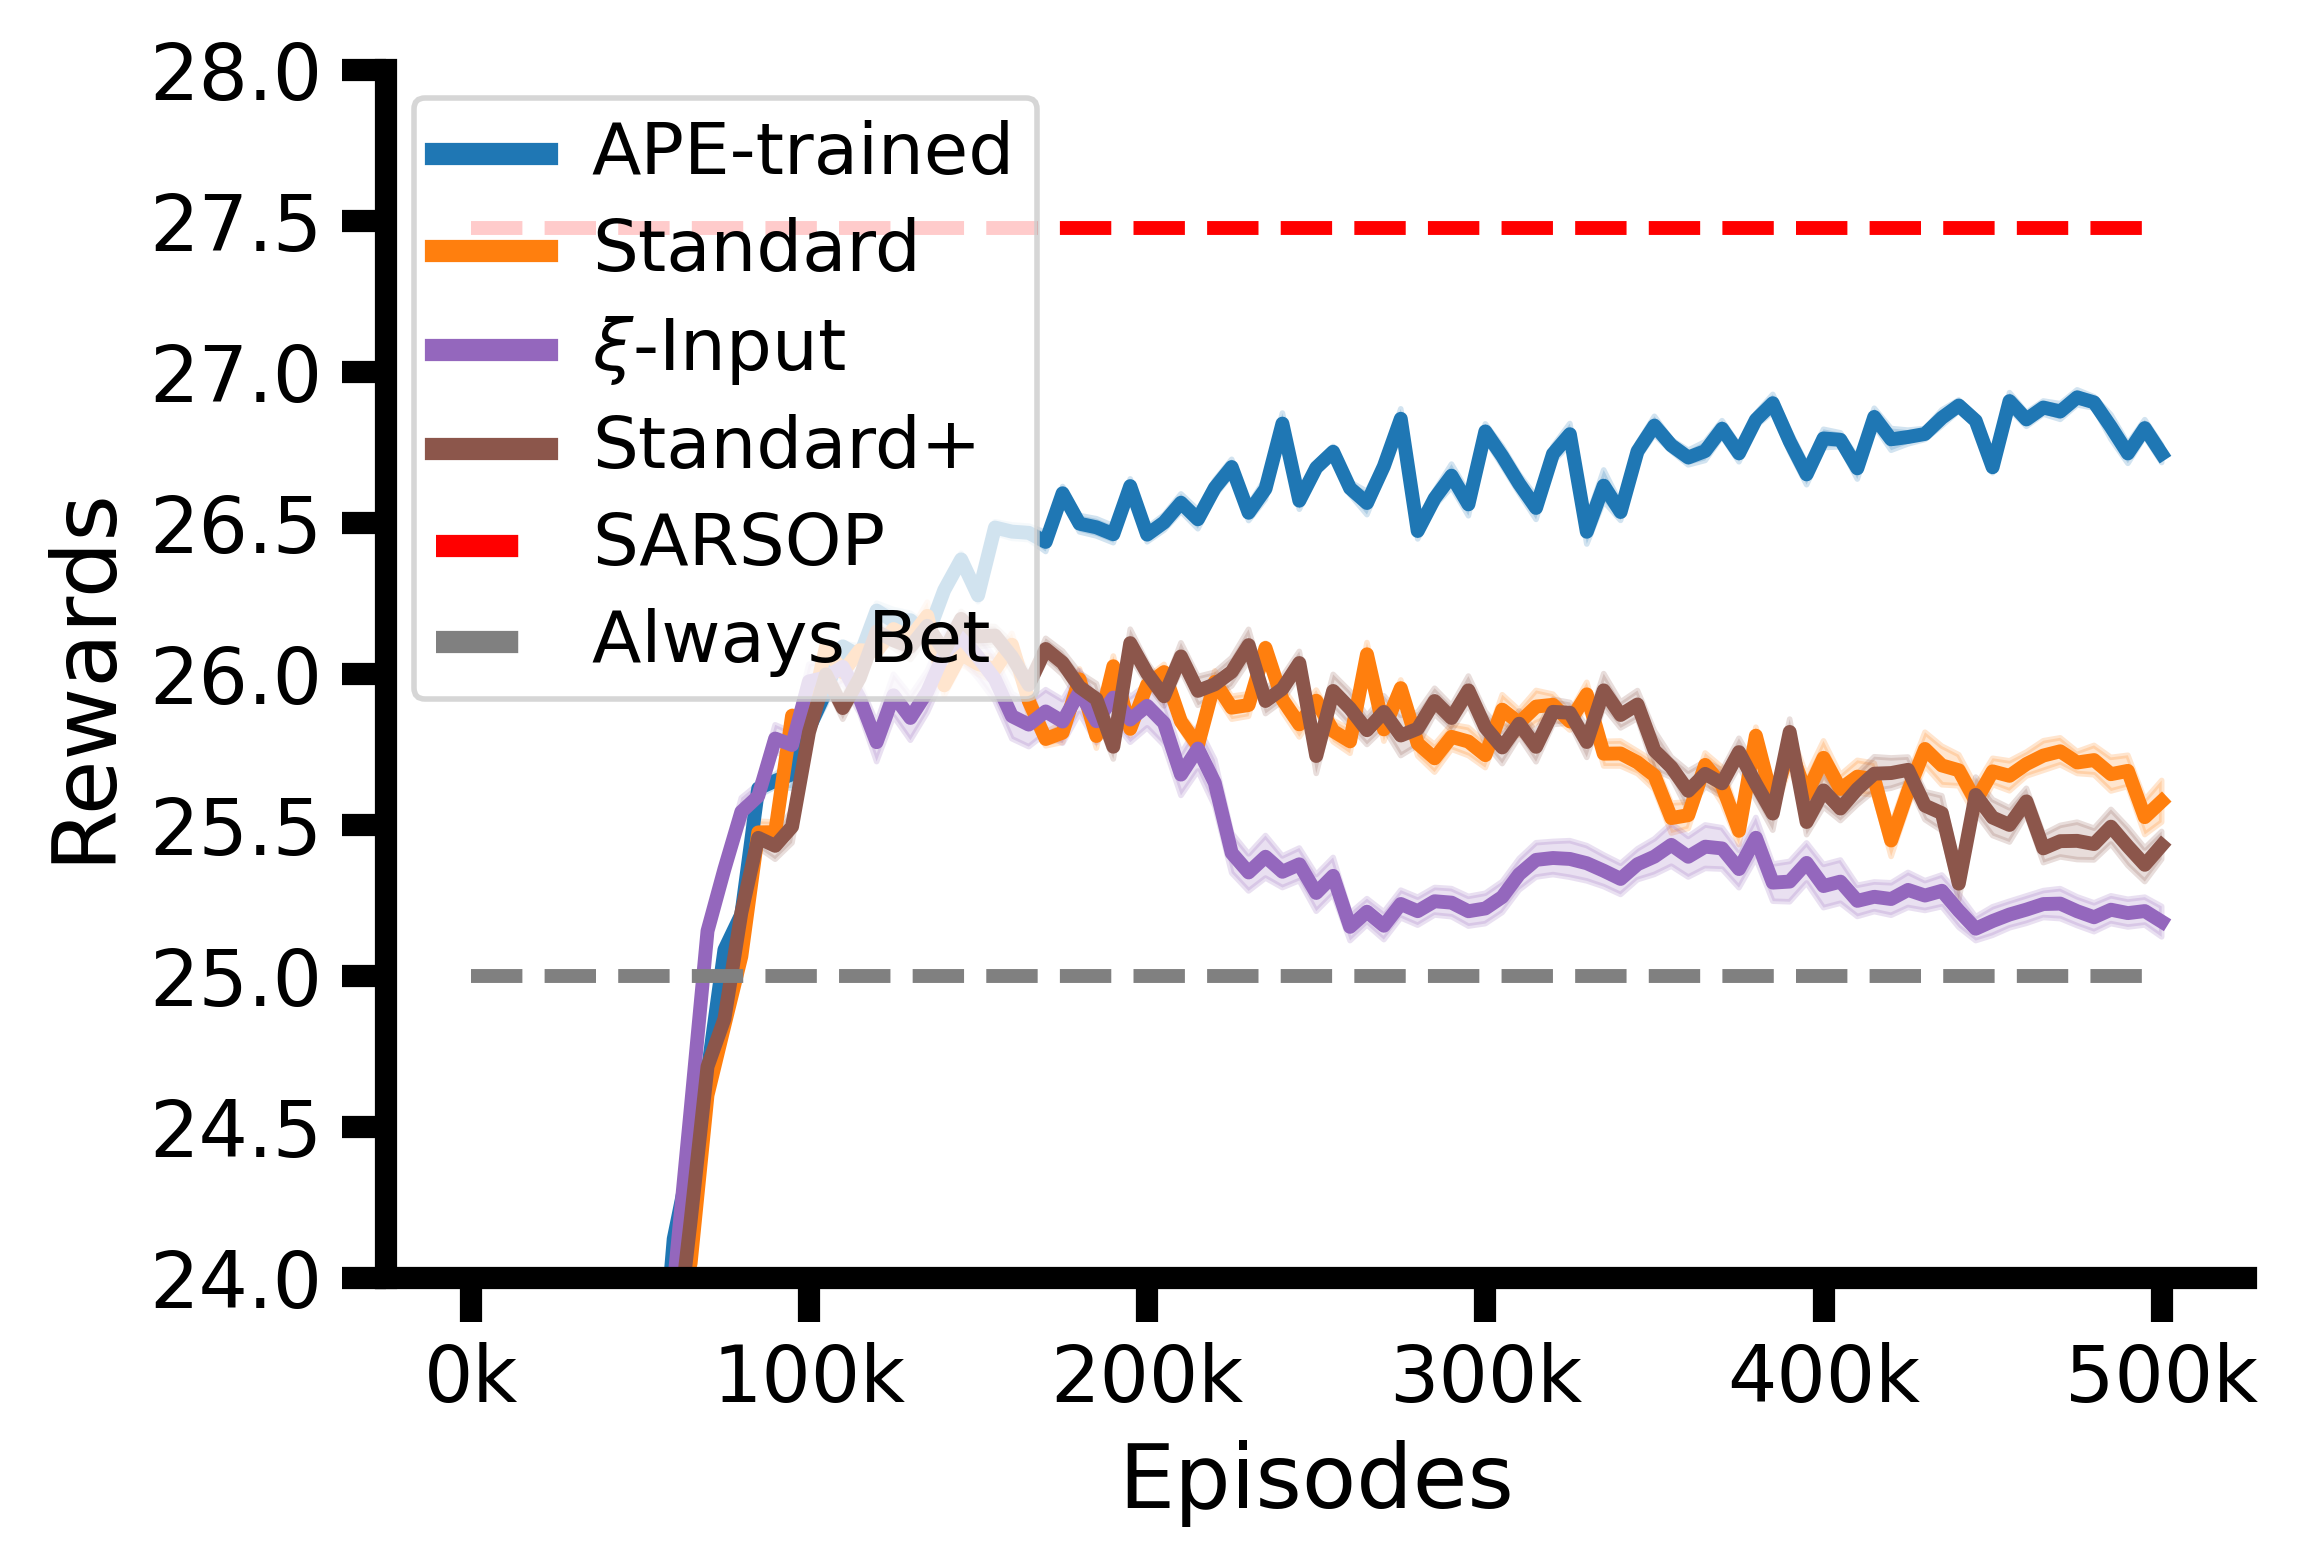

In [ ]:
from matplotlib.ticker import FormatStrFormatter
from settings_ana import colors
from settings_ana import names

x_units = 'k'
x_exp = test_episodes
y_exp = ape_test_rews.T

### preprocessing
y_exp = np.array(y_exp)
means_exp = y_exp.mean(axis=1)
stderr_exp = y_exp.std(axis=1)/np.sqrt(len(y_exp))

y_pomdp = [np.array(rews_pomdp).mean()]*len(x_exp)

y_always_bet = [25]*len(x_exp)

### set up figure
fig = plt.figure(dpi=400)
ax = fig.add_subplot(111)    

### plot
ax.plot(x_exp, means_exp, color=colors['ape'], label=names['ape'])
ax.fill_between(x_exp, means_exp - stderr_exp, means_exp + stderr_exp, color=colors['ape'], alpha=0.2)

ax.plot(x_exp, y_pomdp, color='red', label=names['sarsop'], linestyle='--')

ax.plot(x_exp, y_always_bet, color='grey', label='Always Bet', linestyle='--')

### format axis
ax.set_xlabel('Episodes')
ax.set_ylabel('Rewards')

ax.xaxis.set_major_formatter(FormatStrFormatter('%dk'))

ax.legend(loc='upper left')

ax.set_ylim((24,28))

format_axis(ax)

In [ ]:
fig.savefig(os.path.join(analysis_folder, 'learning_curves.png'))
fig.savefig(os.path.join(analysis_folder, 'learning_curves.svg'))

## Panel B: Number of Observes per Episode 

In [2]:
from settings_ana import pepe_nn_efficacy_at_recurrent_models as ape_models
from utils_project import load_modelrun_files
from settings_ana import timestamps

traj_base = os.path.join('data', 'nns', 'eval', 'pepe', )

cmap_apes = mpl.colormaps['Blues']
cmap_controls = mpl.colormaps['Oranges']
test_taus = np.arange(0, 1.1, 0.125)

rewss_taus_ape, counterss_peeks_taus_ape, control_errss_taus_ape, trajss_actions_taus_ape, trajss_logits_taus_ape, trajss_ps_taus_ape = load_modelrun_files(ape_models, timestamps['pepe_nn_efficacy_at_recurrent_traj'], ape=True, traj_base=traj_base)
    
peeks_pomdp = [0, 0, 0, 0, 4, 5, 5, 6, 7]

peeks_pomdp = np.array([
    [0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0],
    [0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0,	0],
    [2,	2,	2,	2,	2,	2,	2,	2,	2,	2,	2,	2,	2,	2],
    [3,	3,	3,	3,	3,	3,	3,	3,	3,	3,	3,	3,	3,	3],
    [4,	4,	4,  4,	4,	4,	4,	4,	4,	4,	4,	4,	4,	4],
    [4,	4,	4,	4,	4,	4,	4,	4,	4,	4,	4,	4,	4,	4],
    [5,	5,	5,	5,	5,	5,	5,	5,	5,	5,	5,	5,	5,	5],
    [5,	5,	6,	5,	5,	5,	5,	5,	5,	5,	6,	5,	5,	5],
    [6,	6,	5,	5,	6,	5,	6,	6,	6,	6,	6,	5,	5,	6],
]).mean(axis=1)

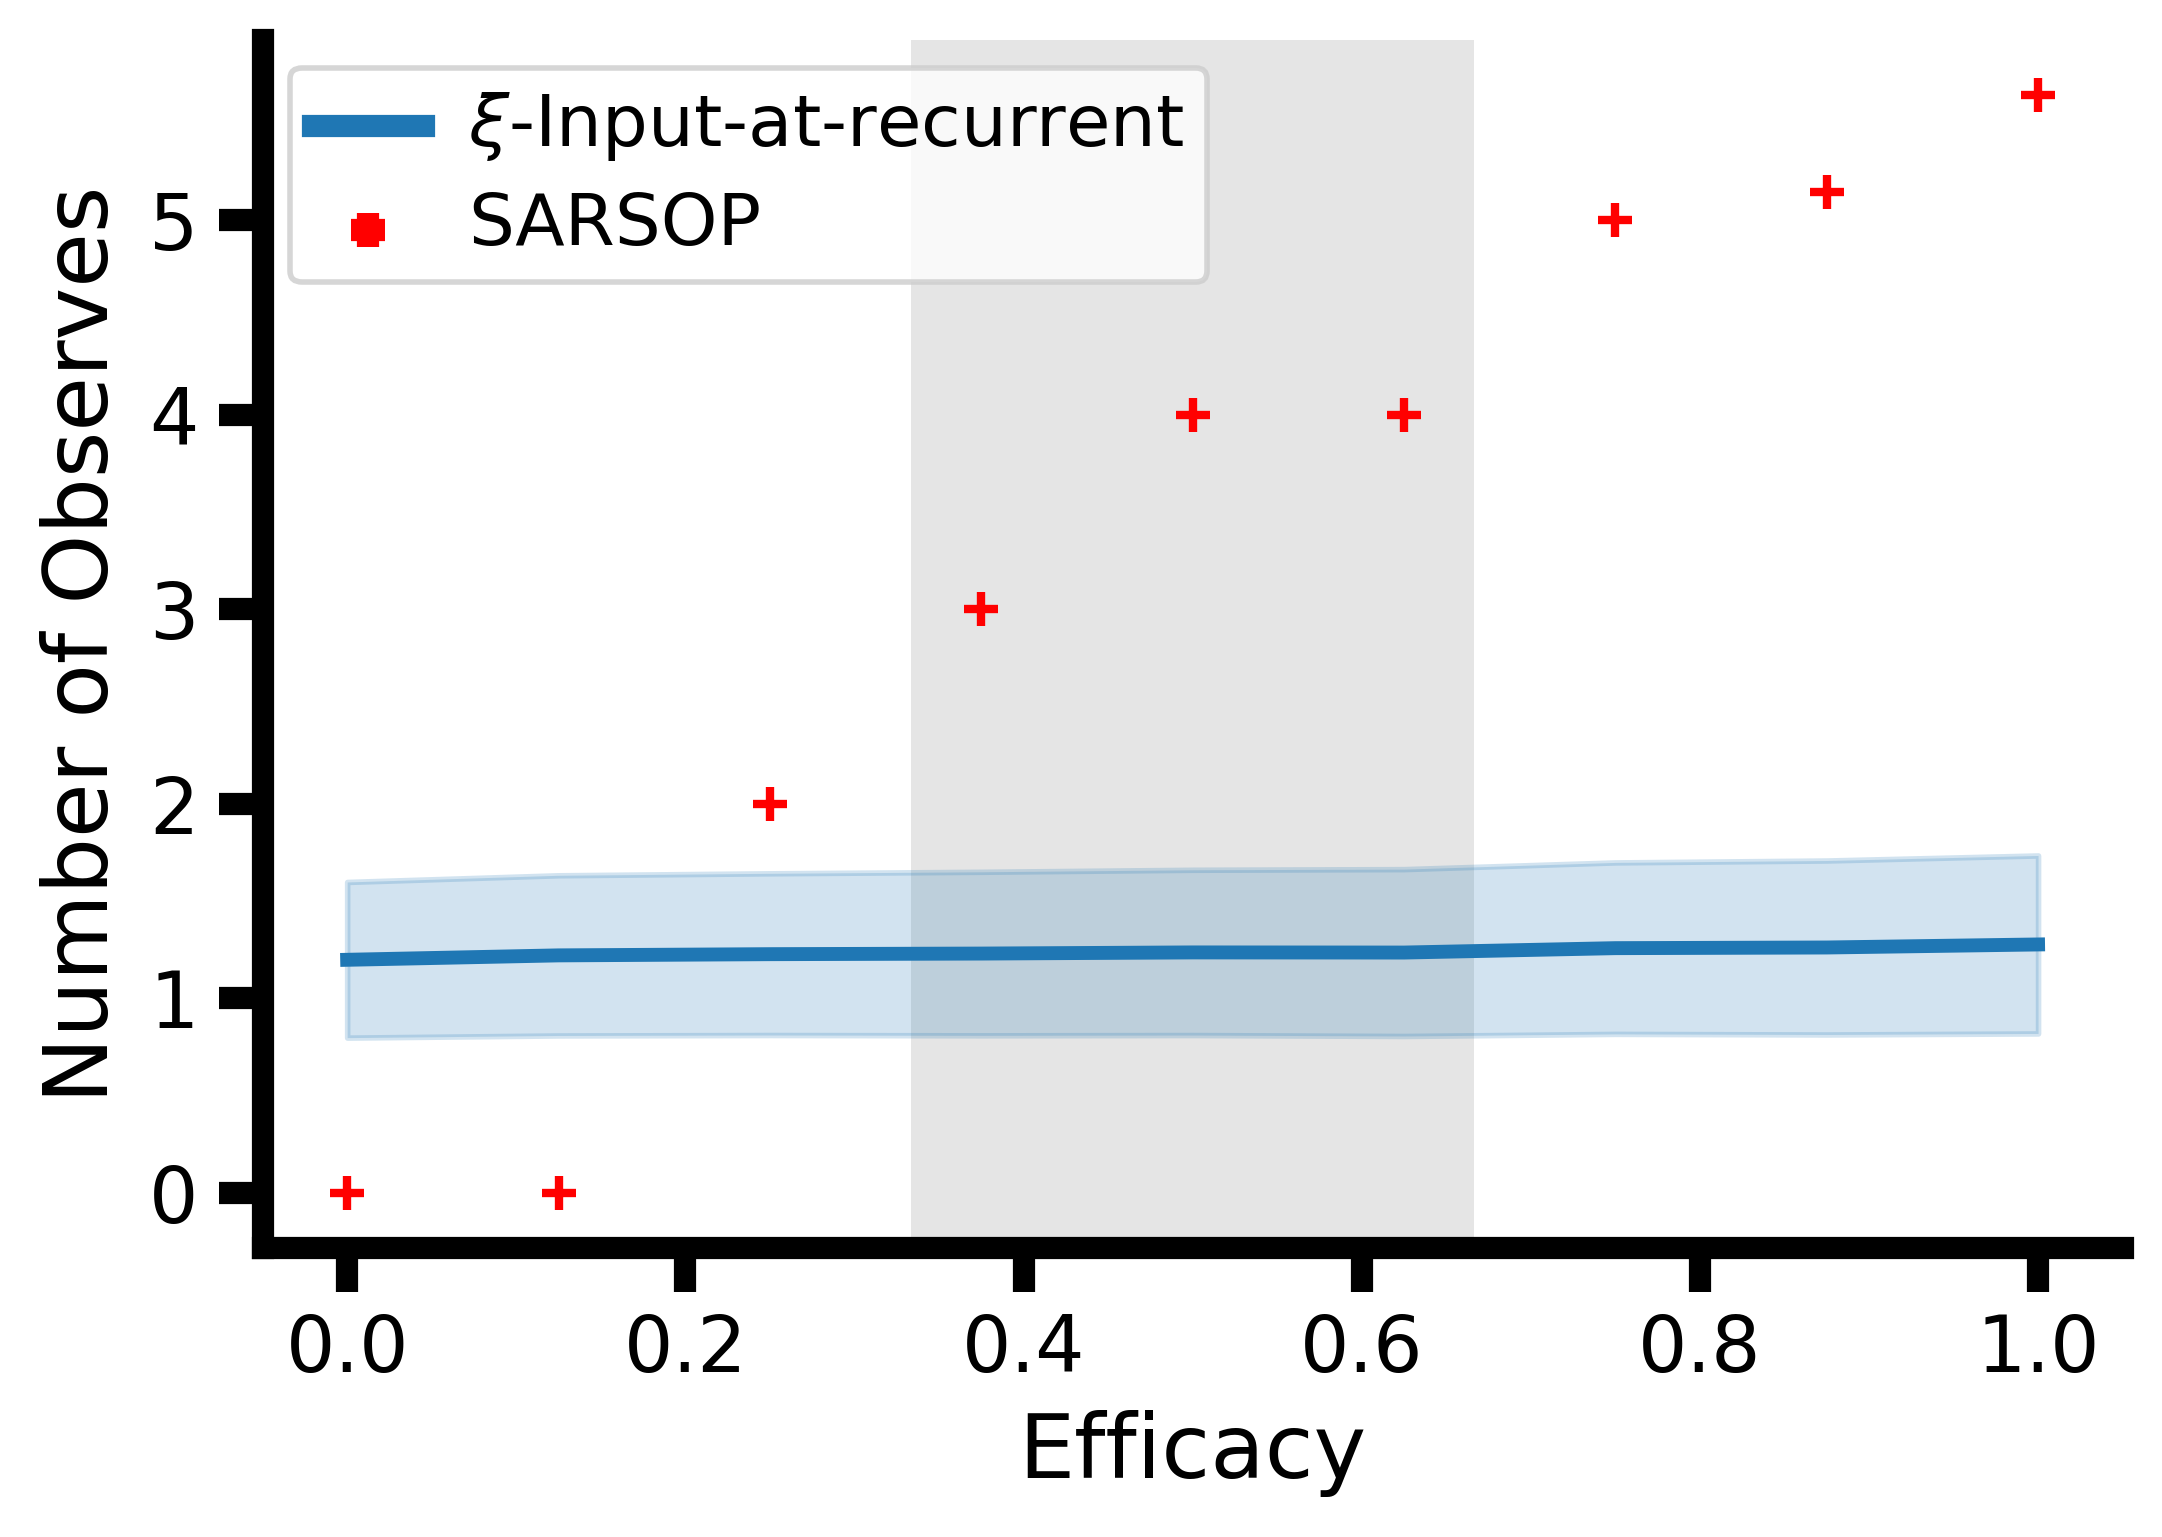

In [3]:
from test_analyses import plot_comparison_curves_several_runs
from settings_ana import colors
from settings_ana import names

fig = plot_comparison_curves_several_runs(test_taus, list(reversed(counterss_peeks_taus_ape)), 
                                          x_theory = test_taus, y_theory = peeks_pomdp, 
                                          label_theory = 'SARSOP', 
                                          axis_xlabel='Efficacy', axis_ylabel='Number of Observes', 
                                          label_exp=names['efficacy_at_recurrent'],
                                          shaded_intervals=[(1/3, 2/3)],
                                          )

In [4]:
fig.savefig(os.path.join(analysis_folder, 'observes_across.png'))
fig.savefig(os.path.join(analysis_folder, 'observes_across.svg'))

## Panel C: Rewards Across Episodes

In [5]:
from settings_ana import pepe_nn_efficacy_at_recurrent_models as ape_models
from utils_project import load_modelrun_files
from settings_ana import pepe_nn_efficacy_at_recurrent_traj_timestamp as traj_timestamp
from settings_ana import timestamps

traj_base = os.path.join('data', 'nns', 'eval', 'pepe', )

test_taus = np.arange(0, 1.1, 0.125)

rewss_taus_ape, counterss_peeks_taus_ape, control_errss_taus_ape, trajss_actions_taus_ape, trajss_logits_taus_ape, trajss_ps_taus_ape = load_modelrun_files(ape_models, traj_timestamp, ape=True, traj_base=traj_base)

rews_pomdp = [25,25,25.33,26.12,27.05,28.06,29.13,30.23,31.36]


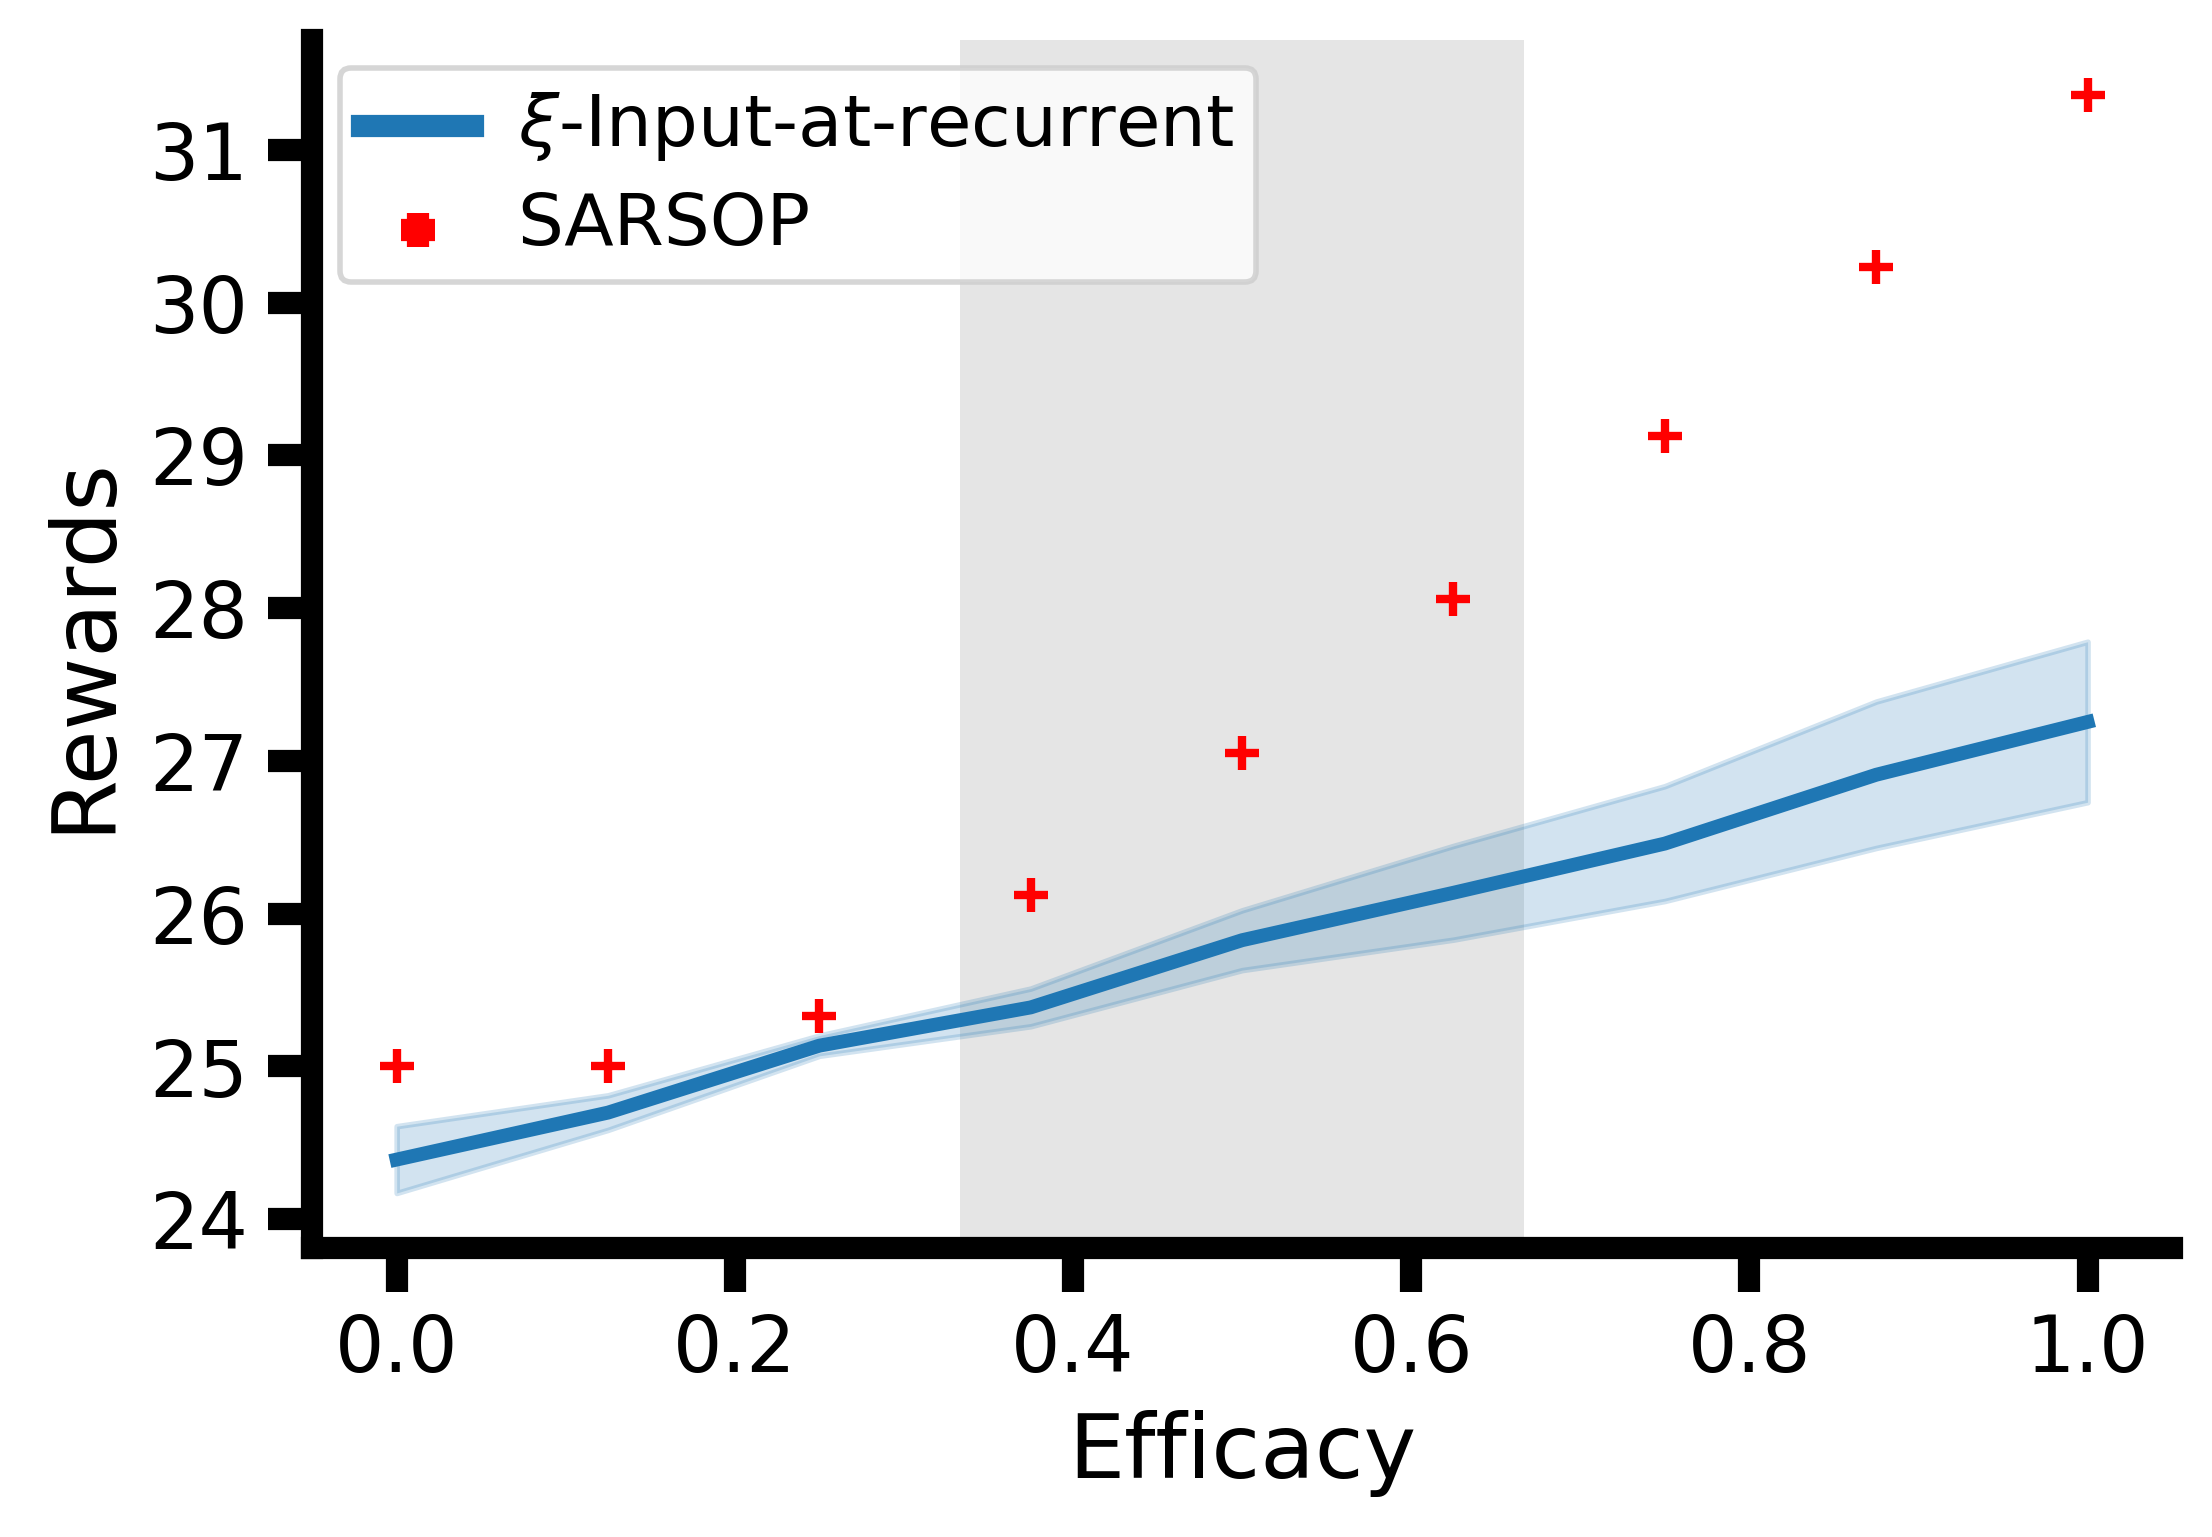

In [6]:
from test_analyses import plot_comparison_curves_several_runs
from settings_ana import colors
from settings_ana import names

fig = plot_comparison_curves_several_runs(test_taus, list(reversed(rewss_taus_ape)),
                                          x_theory = test_taus, y_theory = rews_pomdp,
                                            label_theory = 'SARSOP', 
                                            axis_xlabel='Efficacy', axis_ylabel='Rewards', 
                                            label_exp=names['efficacy_at_recurrent'],
                                            shaded_intervals=[(1/3, 2/3)],)

In [7]:
fig.savefig(os.path.join(analysis_folder, 'rewards_across.png'))
fig.savefig(os.path.join(analysis_folder, 'rewards_across.svg'))